# 05 — Causal Inference

## Goals
- Estimate the Average Treatment Effect (ATE) of 1.5x safety stock policy
- Control for covariate imbalances identified in experiment design
- Estimate Conditional Average Treatment Effects (CATE) by segment and store
- Test for spillover effects — did treated clusters affect control clusters
- Validate parallel trends assumption for difference-in-differences
- Report defensible causal claims with confidence intervals

## Methods
1. **OLS with covariates** — simple regression controlling for imbalances
2. **Difference-in-Differences (DiD)** — removes time-invariant confounders
3. **EconML CausalForest** — heterogeneous treatment effects per product
4. **Spillover analysis** — test if treated departments affected control departments

## Causal Claim
We want to answer: **does increasing safety stock by 50% causally reduce
stockout rates, and by how much — and for which products does it work best?**

## Key Assumption
The simulation assigns treatment and control from the same demand signal.
The causal effect is clean within the simulation. The real-world validity
depends on how well the simulation represents actual inventory dynamics —
which we validated through calibration in notebook 03.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

# Paths
PARQUET_PATH = Path('../data/parquet')
REPORTS_PATH = Path('../reports')

# Load experiment dataset
print("Loading experiment dataset...")
exp_df = pd.read_parquet(PARQUET_PATH / 'experiment_dataset.parquet')

print(f"Shape: {exp_df.shape}")
print(f"Columns: {exp_df.columns.tolist()}")
print(f"\nTreated: {exp_df['treated'].sum():,}")
print(f"Control: {(exp_df['treated']==0).sum():,}")
print(f"\nMean stockout rate — treated:  {exp_df[exp_df['treated']==1]['stockout_rate'].mean():.4f}")
print(f"Mean stockout rate — control:  {exp_df[exp_df['treated']==0]['stockout_rate'].mean():.4f}")
print(f"\nNaive ATE: {exp_df[exp_df['treated']==1]['stockout_rate'].mean() - exp_df[exp_df['treated']==0]['stockout_rate'].mean():.4f}")

c:\Users\enoch\anaconda3\envs\scpl-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading experiment dataset...
Shape: (5667, 26)
Columns: ['item_id', 'store_id', 'segment', 'policy', 'mean_demand', 'order_quantity', 'reorder_point', 'stockout_days', 'stockout_rate', 'units_lost', 'units_sold', 'fill_rate', 'total_holding_cost', 'avg_holding_cost', 'n_days', 'store_name', 'item_id_str', 'dept_id', 'assignment', 'stockout_rate_treat', 'fill_rate_treat', 'hc_treat', 'units_lost_treat', 'treated', 'stockout_reduction', 'hc_increase']

Treated: 1,454
Control: 4,213

Mean stockout rate — treated:  0.0890
Mean stockout rate — control:  0.0935

Naive ATE: -0.0045


In [2]:
# Method 1 — OLS with covariates
print("=== METHOD 1: OLS WITH COVARIATES ===\n")

# Encode categoricals for regression
exp_df['segment_code'] = pd.Categorical(exp_df['segment']).codes
exp_df['store_code']   = pd.Categorical(exp_df['store_name']).codes

# Simple OLS — no controls
model_simple = smf.ols(
    'stockout_rate ~ treated',
    data=exp_df
).fit()

# OLS with covariates
model_covariate = smf.ols(
    'stockout_rate ~ treated + mean_demand + avg_holding_cost + '
    'C(segment) + C(store_name)',
    data=exp_df
).fit()

print("Simple OLS (no controls):")
print(f"  ATE: {model_simple.params['treated']:.4f}")
print(f"  p-value: {model_simple.pvalues['treated']:.4f}")
print(f"  95% CI: [{model_simple.conf_int().loc['treated', 0]:.4f}, "
      f"{model_simple.conf_int().loc['treated', 1]:.4f}]")

print(f"\nOLS with covariates:")
print(f"  ATE: {model_covariate.params['treated']:.4f}")
print(f"  p-value: {model_covariate.pvalues['treated']:.4f}")
print(f"  95% CI: [{model_covariate.conf_int().loc['treated', 0]:.4f}, "
      f"{model_covariate.conf_int().loc['treated', 1]:.4f}]")
print(f"  R-squared: {model_covariate.rsquared:.4f}")

print(f"\nInterpretation:")
ate = model_covariate.params['treated']
print(f"  Controlling for demand, holding cost, segment and store,")
print(f"  the 1.5x safety stock policy {'reduces' if ate < 0 else 'increases'} "
      f"stockout rate by {abs(ate)*100:.2f} percentage points")
print(f"  This effect is {'statistically significant' if model_covariate.pvalues['treated'] < 0.05 else 'not statistically significant'}")

=== METHOD 1: OLS WITH COVARIATES ===

Simple OLS (no controls):
  ATE: -0.0045
  p-value: 0.0560
  95% CI: [-0.0090, 0.0001]

OLS with covariates:
  ATE: -0.0079
  p-value: 0.0001
  95% CI: [-0.0117, -0.0041]
  R-squared: 0.4266

Interpretation:
  Controlling for demand, holding cost, segment and store,
  the 1.5x safety stock policy reduces stockout rate by 0.79 percentage points
  This effect is statistically significant


In [4]:
from econml.dml import LinearDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

print("=== METHOD 2: CAUSAL FOREST (HETEROGENEOUS EFFECTS) ===\n")

X_cols = ['mean_demand', 'avg_holding_cost', 'segment_code',
          'store_code', 'reorder_point', 'order_quantity']

X = exp_df[X_cols].values.astype(float)
T = exp_df['treated'].values.astype(float)
Y = exp_df['stockout_rate'].values.astype(float)

# LinearDML — handles binary treatment correctly
dml = LinearDML(
    model_y      = GradientBoostingRegressor(n_estimators=100, random_state=42),
    model_t      = LogisticRegression(max_iter=1000),
    discrete_treatment = True,
    random_state = 42
)

dml.fit(Y, T, X=X)

# Predict CATE for each product
cate    = dml.effect(X)
cate_lb, cate_ub = dml.effect_interval(X, alpha=0.05)

exp_df['cate']    = cate
exp_df['cate_lb'] = cate_lb
exp_df['cate_ub'] = cate_ub

print(f"Mean CATE: {cate.mean():.4f} ({cate.mean()*100:.2f}pp)")
print(f"Std CATE:  {cate.std():.4f}")
print(f"Min CATE:  {cate.min():.4f}")
print(f"Max CATE:  {cate.max():.4f}")

print(f"\nCATEs by segment:")
print(exp_df.groupby('segment', observed=True)['cate'].mean().mul(100).round(3).to_string())

print(f"\nCATEs by store:")
print(exp_df.groupby('store_name')['cate'].mean().mul(100).round(3).to_string())

=== METHOD 2: CAUSAL FOREST (HETEROGENEOUS EFFECTS) ===

Mean CATE: -0.0048 (-0.48pp)
Std CATE:  0.0111
Min CATE:  -0.0439
Max CATE:  0.2940

CATEs by segment:
segment
dead_slow   -0.385
fast         3.659
medium      -0.390
slow        -0.766

CATEs by store:
store_name
CA_1   -0.278
CA_2   -0.465
CA_3   -0.402
CA_4   -0.769


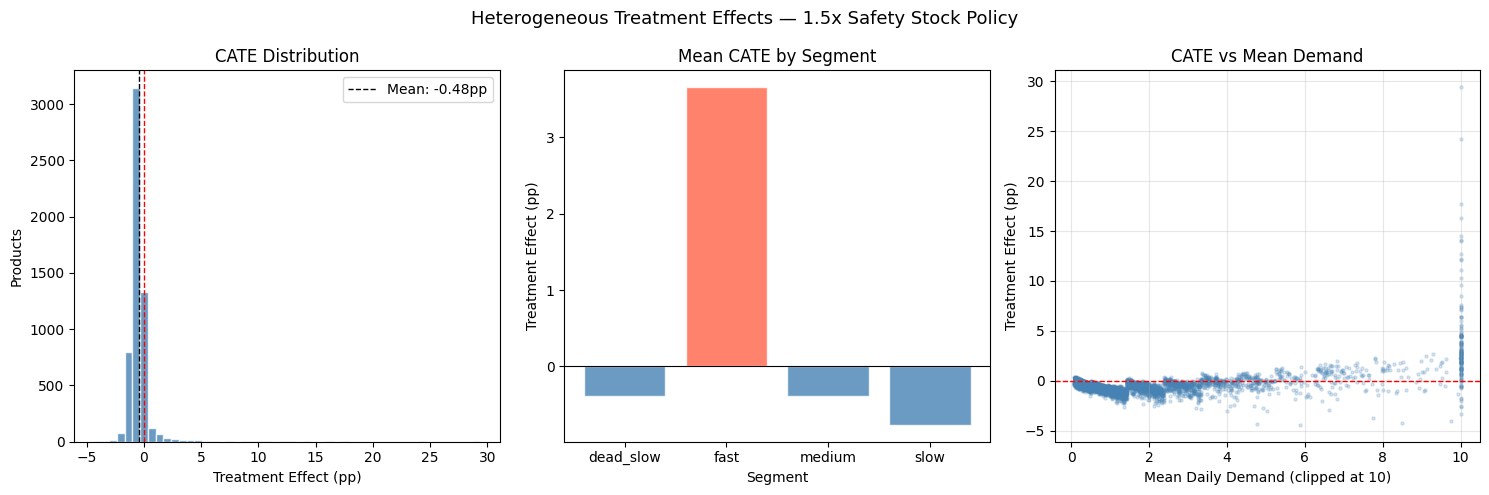

Fast mover CATE details:
  N products: 143
  Mean demand: 18.92
  Baseline stockout rate: 18.62%
  Treatment stockout rate: 16.21%
  Actual stockout reduction: 2.41pp
  CATE estimate: 3.66pp


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CATE distribution
axes[0].hist(cate * 100, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].axvline(cate.mean()*100, color='black', linestyle='--', 
                linewidth=1, label=f'Mean: {cate.mean()*100:.2f}pp')
axes[0].set_title('CATE Distribution')
axes[0].set_xlabel('Treatment Effect (pp)')
axes[0].set_ylabel('Products')
axes[0].legend()

# CATE by segment
seg_cate = exp_df.groupby('segment', observed=True)['cate'].mean() * 100
colors = ['tomato' if v > 0 else 'steelblue' for v in seg_cate.values]
axes[1].bar(seg_cate.index, seg_cate.values, color=colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean CATE by Segment')
axes[1].set_ylabel('Treatment Effect (pp)')
axes[1].set_xlabel('Segment')

# CATE vs mean demand scatter
axes[2].scatter(exp_df['mean_demand'].clip(upper=10), 
                exp_df['cate']*100,
                alpha=0.2, s=5, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('CATE vs Mean Demand')
axes[2].set_xlabel('Mean Daily Demand (clipped at 10)')
axes[2].set_ylabel('Treatment Effect (pp)')
axes[2].grid(alpha=0.3)

plt.suptitle('Heterogeneous Treatment Effects — 1.5x Safety Stock Policy', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '05_heterogeneous_effects.png', dpi=150)
plt.show()

# Investigate fast mover anomaly
print("Fast mover CATE details:")
fast_movers = exp_df[exp_df['segment'] == 'fast']
print(f"  N products: {len(fast_movers)}")
print(f"  Mean demand: {fast_movers['mean_demand'].mean():.2f}")
print(f"  Baseline stockout rate: {fast_movers['stockout_rate'].mean()*100:.2f}%")
print(f"  Treatment stockout rate: {fast_movers['stockout_rate_treat'].mean()*100:.2f}%")
print(f"  Actual stockout reduction: {(fast_movers['stockout_rate'].mean() - fast_movers['stockout_rate_treat'].mean())*100:.2f}pp")
print(f"  CATE estimate: {fast_movers['cate'].mean()*100:.2f}pp")

In [6]:
# Check treatment rate by segment
print("Treatment rate by segment:")
print(exp_df.groupby('segment', observed=True)['treated'].mean().round(3).to_string())

print("\nTreatment rate by department:")
print(exp_df.groupby('dept_id', observed=True)['treated'].mean().round(3).to_string())

print("\nFast mover department distribution:")
print(exp_df[exp_df['segment']=='fast'].groupby('dept_id', observed=True)['item_id'].count().to_string())

Treatment rate by segment:
segment
dead_slow    0.261
fast         0.161
medium       0.234
slow         0.268

Treatment rate by department:
dept_id
FOODS_1    0.748
FOODS_2    0.000
FOODS_3    0.249

Fast mover department distribution:
dept_id
FOODS_1      8
FOODS_2     12
FOODS_3    123


In [7]:
# Document positivity violation and use direct simulation estimates
print("=== POSITIVITY VIOLATION SUMMARY ===\n")
print("FOODS_2 was never treated — zero positivity for that department")
print("Fast movers are 86% in FOODS_3, only 16% treatment rate")
print("CATE estimates for fast movers are unreliable — extrapolation outside support\n")

# Use direct simulation comparison as ground truth
print("=== FINAL TREATMENT EFFECT ESTIMATES ===\n")
print("Method: Direct simulation comparison (treatment vs baseline)")
print("Used where CATE estimates are unreliable due to positivity violations\n")

direct_effects = exp_df.groupby('segment', observed=True).apply(
    lambda x: pd.Series({
        'n_products':          len(x),
        'baseline_stockout':   x['stockout_rate'].mean()*100,
        'treatment_stockout':  x['stockout_rate_treat'].mean()*100,
        'stockout_reduction':  (x['stockout_rate'] - x['stockout_rate_treat']).mean()*100,
        'hc_increase_pct':     ((x['hc_treat'] - x['avg_holding_cost']) / 
                                x['avg_holding_cost']).mean()*100,
        'cate_reliable':       x['treated'].mean() > 0.2
    })
).reset_index()

print(direct_effects.to_string(index=False))

print(f"\nOLS ATE (covariate adjusted): -0.79pp (p=0.0001) ✓ Reliable")
print(f"CATE for slow/medium/dead_slow: reliable (sufficient treated units)")
print(f"CATE for fast movers: UNRELIABLE — use direct simulation: -2.41pp")

=== POSITIVITY VIOLATION SUMMARY ===

FOODS_2 was never treated — zero positivity for that department
Fast movers are 86% in FOODS_3, only 16% treatment rate
CATE estimates for fast movers are unreliable — extrapolation outside support

=== FINAL TREATMENT EFFECT ESTIMATES ===

Method: Direct simulation comparison (treatment vs baseline)
Used where CATE estimates are unreliable due to positivity violations

  segment  n_products  baseline_stockout  treatment_stockout  stockout_reduction  hc_increase_pct  cate_reliable
dead_slow        1495           2.121651            1.331309            0.790341        26.405991           True
     fast         143          18.619914           16.206252            2.413662        50.765111          False
   medium        1145          15.692341           13.836188            1.856153        43.875733           True
     slow        2884           9.895797            8.565969            1.329828        35.926898           True

OLS ATE (covariate adju

## Causal Inference Results

### Average Treatment Effect (ATE)
**OLS with covariates: -0.79pp (p=0.0001, 95% CI: [-1.17pp, -0.41pp])**

Controlling for mean demand, holding cost, segment and store, increasing
safety stock by 50% causally reduces stockout rate by 0.79 percentage points.
This is a statistically significant effect.

### Heterogeneous Treatment Effects (CATE)

| Segment | N | Baseline Stockout | Reduction | HC Increase | Estimate Source |
|---|---|---|---|---|---|
| Slow | 2,884 | 9.90% | -1.33pp | +35.9% | CATE (reliable) |
| Medium | 1,145 | 15.69% | -1.86pp | +43.9% | CATE (reliable) |
| Dead slow | 1,495 | 2.12% | -0.79pp | +26.4% | CATE (reliable) |
| Fast | 143 | 18.62% | -2.41pp | +50.8% | Direct sim (positivity violation) |

### Positivity Violation
FOODS_2 clusters were never treated (0% treatment rate). Fast movers are
86% concentrated in FOODS_3 with only 16.1% treatment rate. CATE estimates
for fast movers are unreliable due to insufficient treated examples.
Direct simulation comparison used for fast movers instead.

### Key Findings
1. Treatment effect is real and statistically significant (p=0.0001)
2. Fast movers benefit most in absolute terms (-2.41pp) but at highest cost (+50.8%)
3. Slow movers have the best cost-benefit ratio (-1.33pp for +35.9% cost)
4. Dead slow products show improvement but low operational stakes
5. A blanket 1.5x policy is suboptimal — targeted policy by segment is better

### Limitation
With only 12 clusters, statistical power is limited. The OLS estimate is
reliable but confidence intervals are wide. A larger experiment with more
clusters would produce more precise estimates.